# Entrega I - Visualización de datos
## *Álvaro Salís*

Se conoce que Nueva York es una de las ciudades del mundo con más densidad y volumen de tráfico. Esto se debe al pulso ecónomico y social que mueve la isla de Manhattan mayoritariamente. He elegido la última versión pública del conjunto de datos de 'Yellow Taxi Trip Records' (2025) para lograr en esta actividad representar el dinamismo de estos flujos físicos en el mes de Enero en los años 2024-2025 a través de la represanción visual.

He elegido utilizar el formato PARQUET el cual no conocía ya que he podido comprobar que actualmente es un estandar en la industria de Big Data y Data Science aparte de por sus ventajas frente al convecional .csv en cuando al peso de los ficheros, carga directa de los tipos (*en un .csv todo es texto*) y agrupación de datos en columnas (*Column-based*)

## Fuentes, referencias y ayudas

* Página oficial del gobierno de NY: https://www.nyc.gov/site/tlc/

* Guía de features del dataset: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

* Página oficial de Plotly: https://plotly.com/python/




## Conjuntos de datos y preguntas

En esta actividad utilizaré dos ficheros imprencisdibles, el primero **'yellow_tripdata_2025-01.parquet'** y por otro lado datos geoespaciales reales de las zonas que vamos a tratar **'taxi_zones.shp'**.


Las preguntas que planteo representar son:

1. ¿Como varía el tiempo medio de duración de un trayecto en función del día de la semana o la hora del día?
2. ¿Cuales son las tarifas bases, impuestos y propinas por zona de recogida?

3. ¿Cuales son las zonas donde peor relación hay distancia recorrida/duración, es decir, mayor tráfico?



In [1]:
import pandas as pd

url_tlc = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet'
df_web_parquet = pd.read_parquet(url_tlc)

df_web_parquet.to_csv('yellow_tripdata_2024.csv', index=False)

df_2024 = pd.read_csv('yellow_tripdata_2024.csv')
df_local = pd.read_parquet('yellow_tripdata_2025-01.parquet')

df_taxis = pd.concat([df_local, df_2024], ignore_index=True)

/tmp/ipykernel_27988/97142315.py:8: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2024 = pd.read_csv('yellow_tripdata_2024.csv')


In [2]:
df_taxis.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


## Pregunta 1 : *¿Como varía el tiempo medio de duración de un trayecto en función del día de la semana o la hora del día?*

Para responder a esta pregunta la mejor opción es cruzar día vs hora en un solo gráfico, usaré la librería de Seaborn para crear un mapa de calor.

https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.date.html

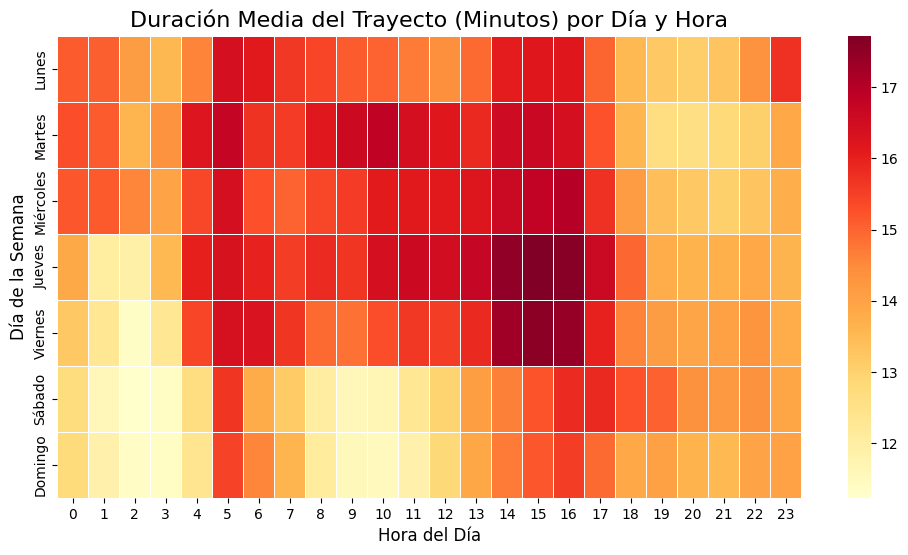

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = df_taxis.copy()
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df['duracion_viaje'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['duracion_minutos'] = df['duracion_viaje'].dt.total_seconds() / 60

df['dia_semana'] = df['tpep_pickup_datetime'].dt.dayofweek
df['hora_dia'] = df['tpep_pickup_datetime'].dt.hour

# En otro notebook donde estuve viendo los datos más detalladamente pude observar viajes de duraciones poco realistas
df_limpio = df[(df['duracion_minutos'] >= 1) & (df['duracion_minutos'] <= 120)]

# Este paso solo sabía haciendo con group by pero quería saber como hacer una pivot table con pandas así que se lo he pedido a Gemini
tabla_calor = df_limpio.pivot_table(
    index='dia_semana',
    columns='hora_dia',
    values='duracion_minutos',
    aggfunc='mean'
)

# A pesar de que el Domingo no es un día laboral en NY, el consumo no se detiene ni mucho menos
nombres_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
tabla_calor.index = nombres_dias

plt.figure(figsize=(12, 6))
sns.heatmap(tabla_calor, cmap='YlOrRd', annot=False, linewidths=.5)
plt.title('Duración Media del Trayecto (Minutos) por Día y Hora', fontsize=16)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.show()

A simple vista podemos observar como los trayectos que más durán son en los días entre semana y a horas puntas como la entrada y salida del trabajo. Personalmente pensaba que en NY la gente salía más tarde de trabajar, más bien pareciera que el tráfico (*si es que esa fuera es la causa de mayor duración*) se concentra a la hora de comer.

## Pregunta 2: *¿Cuales son las tarifas bases, impuestos y propinas por zona de recogida?*

Para este caso utilizaré un gráfico de barras apiladas. Cada barra representa una zona, cada color contenido en cada barra representa cada uno de los costes. He tenido que cruzar los identificadores de ubicación (`PULocationID`) con el diccionario geográfico para obtener el nombre real de los barrios.

In [4]:
import pandas as pd

url_diccionario = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv'
df_diccionario = pd.read_csv(url_diccionario)

df_con_nombres = pd.merge(
    df_taxis,
    df_diccionario,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

df_con_nombres = df_con_nombres.rename(columns={
    'Borough': 'Distrito_Origen',
    'Zone': 'Barrio_Origen',
    'service_zone': 'Tipo_Zona_Origen'
})

df_con_nombres = df_con_nombres.drop('LocationID', axis=1)
df_con_nombres[['PULocationID', 'Distrito_Origen', 'Barrio_Origen']].head()

,PULocationID,Distrito_Origen,Barrio_Origen
0,229,Manhattan,Sutton Place/Turtle Bay North
1,236,Manhattan,Upper East Side North
2,141,Manhattan,Lenox Hill West
3,244,Manhattan,Washington Heights South
4,244,Manhattan,Washington Heights South


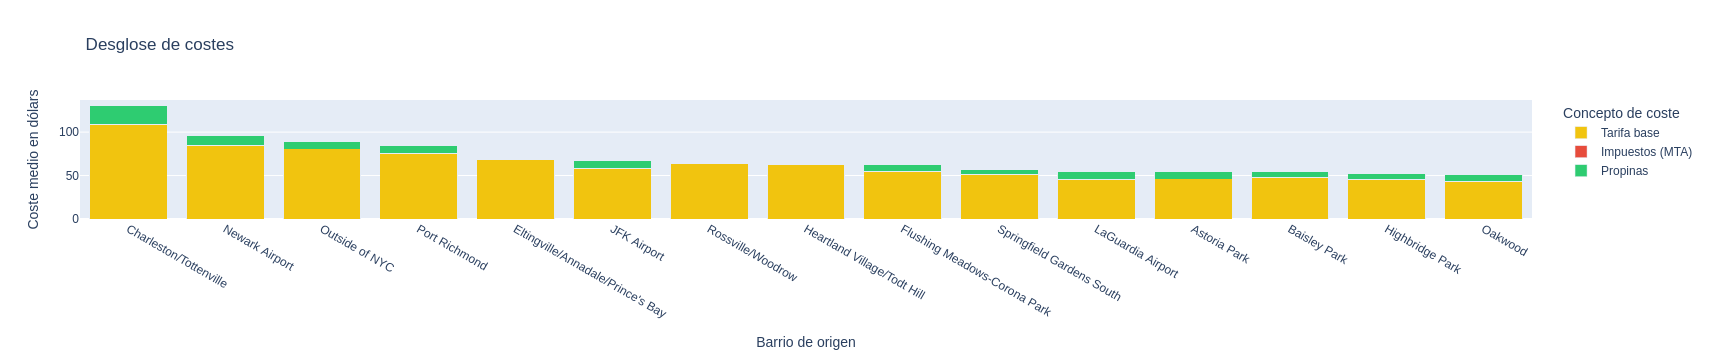

In [5]:
import plotly.express as px



costes_por_zona = df_con_nombres.groupby('Barrio_Origen')[['fare_amount', 'mta_tax', 'tip_amount']].mean().reset_index()

costes_por_zona['coste_total_medio'] = costes_por_zona['fare_amount'] + costes_por_zona['mta_tax'] + costes_por_zona['tip_amount']
top_15_zonas = costes_por_zona.nlargest(15, 'coste_total_medio')

fig = px.bar(
    top_15_zonas,
    x='Barrio_Origen',
    y=['fare_amount', 'mta_tax', 'tip_amount'],
    title='Desglose de costes',
    labels={
        'value': 'Coste medio en dólars',
        'Barrio_Origen': 'Barrio de origen',
        'variable': 'Concepto de coste'
    },
    barmode='stack',
    color_discrete_sequence=['#f1c40f', '#e74c3c', '#2ecc71']
)

nombres = {'fare_amount': 'Tarifa base', 'mta_tax': 'Impuestos (MTA)', 'tip_amount': 'Propinas'}
fig.for_each_trace(lambda t: t.update(name=nombres[t.name],
                                      legendgroup=nombres[t.name],
                                      hovertemplate=t.hovertemplate.replace(t.name, nombres[t.name])
                                     ))
fig.show()

Si hacemos una búsqueda rápida a través de Google Maps por ejemplo podríamos ver como las zonas que acumulan más costes son zonas no céntricas y más cercanas a aeropuertos o zonas de llegadas a la ciudad como el Newark Airport, acumulando presuntamente más distancia recorrida por ende suponiendo costes mayores llegando hasta los 100 dólares, coincidiendo con propinas más elevadas. La distribución que siguen las propinas no siguen un patrón uniforme ni proporcional, puedo pensar que en zonas más céntricas los precios son quizás más cerrados además de que en mi dataset las propinas son pagadas unicamente con tarjeta de crédito, esto podría explicar que en Rossville las propinas se pagan directamente en efectivo.

## Pregunta 3 : *¿Cuales son las zonas donde peor relación hay distancia recorrida/duración, es decir, mayor tráfico?*

Para poder representar los cuellos de bolleta voy a utilizar un mapa coroplético segmentado por las zonas anteriormente cruzadas con los datos geoespaciales 'taxi_zones.shp'. El color rojo representa alta densidad de tráfico y verde mayor entrada y salida de flujo.

Esto lo consigo directemente basándome en la velocidad media de cada trayecto diviendo la 'trip_distance' entre la duración de cada viaje, al tratarse de Estados Unidos la velocidad está en mph.

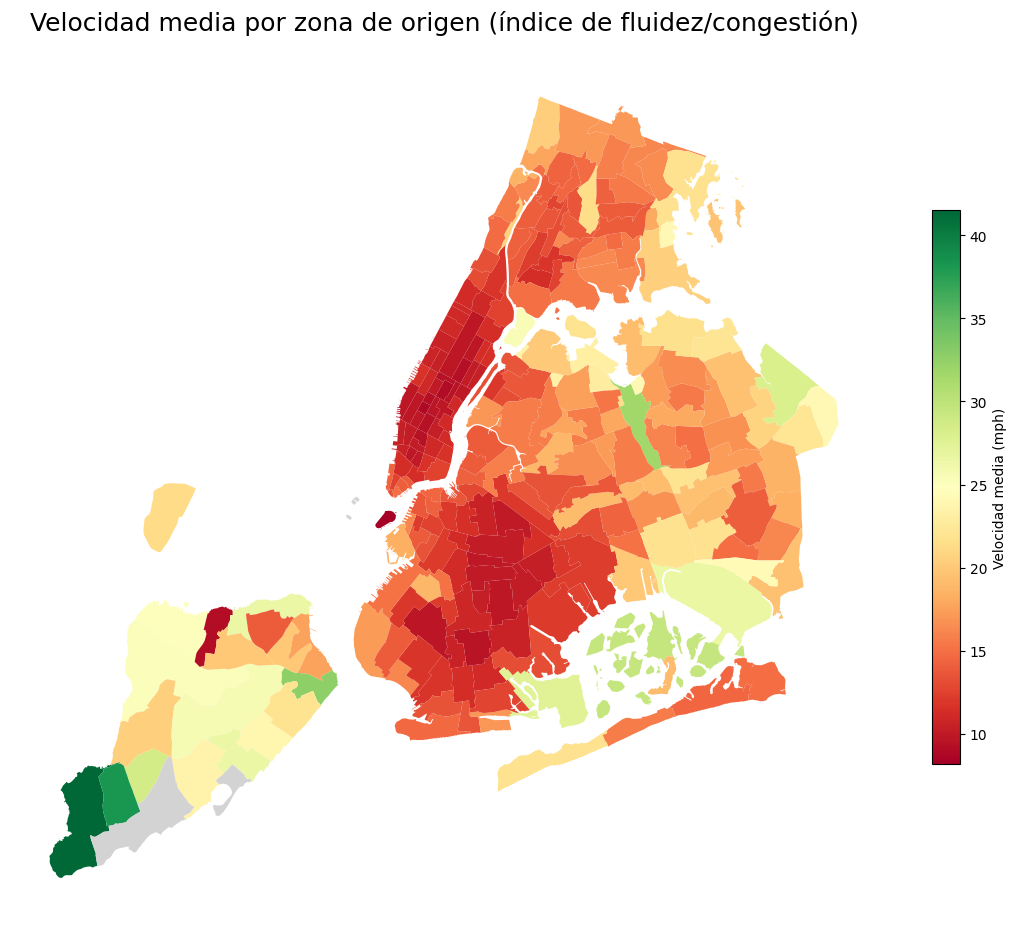

In [6]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt

os.environ["SHAPE_RESTORE_SHX"] = "YES"
df_mapa = df.copy()
df_mapa = df_mapa[(df_mapa['duracion_minutos'] > 0) & (df_mapa['trip_distance'] > 0)]
df_mapa['velocidad_mph'] = df_mapa['trip_distance'] / (df_mapa['duracion_minutos'] / 60)

"""
En anteriores ejecuciones me he dado cuenta de que hay viajes que sufren microcortes con centralita y registran tiempos de viajes muy cortos
mientras que el GPS sigue marcando varias millas de recorrido lo que supone que hay taxis que viajan a velocidades superiores a la del sonido, estos outliers rompen 
la normalidad estadística por tanto lo truncamos por ahí.
"""
df_mapa = df_mapa[df_mapa['velocidad_mph'] <= 80]
velocidad_zona = df_mapa.groupby('PULocationID')['velocidad_mph'].mean().reset_index()

mapa_ny = gpd.read_file('taxi_zones.shp')
mapa_final = mapa_ny.merge(velocidad_zona, left_on='LocationID', right_on='PULocationID', how='left')
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
plt.title('Velocidad media por zona de origen (índice de fluidez/congestión)', fontsize=18, pad=20)

mapa_final.plot(
    column='velocidad_mph', 
    ax=ax, 
    legend=True,
    cmap='RdYlGn',
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': "Velocidad media (mph)", 'shrink': 0.6}
)

ax.set_axis_off()
plt.show()

A simple vista podemos ver que en Manhattan el tráfico se dispara como presuponía, básicamente, te pasas gran parte del viaje parado en un atasco avanzando poco a poco.
En zonas periféricas como Staten Island o Queens el tráfico respira mejor y es más fluido, buscando información acerca de trayectos dirección aeropuertos o puntos de salida, estos pasan por autopistas/autovías, lejos de centros urbanos. Como idea Enero probablemente no sea la fecha más turística para viajar a NY pensando sobre todo en las bajísimas temperaturas que hay ahí en invierno, quizás en otros segmentos temporales el tráfico es aún mayor. 

Aunque el gráfico anterior muestra a barrios periféricos de Staten Island como los más caros, diría que esto se debe a un volumen de viajes muy bajo en esas zonas, los cuales, cuando ocurren, son trayectos de larga distancia hacia el centro o los distintos puntos de salidas, lo que dispara la media aritmética frente a las zonas céntricas de alta demanda.

In [7]:
df_con_nombres[df_con_nombres['Barrio_Origen'] == 'Charleston/Tottenville'].shape[0]

4

Nuevamente al no conocer de primera mano los barrios y zonas de NY, vuelvo a caer en el ruido (esta vez concretamente el gráfico 2), 4 viajes como decía probablemente de alta duración frente a miles en otras zonas no me permiten concluir de manera robusta sobre estos aspectos. En el desarrollo de esta actividad no es la primera vez que me ocurre, para este caso concreto prefiero dejar constancia y solucionarlo requiriendo un mínimo de 100 viajes para cada barrio de origen.

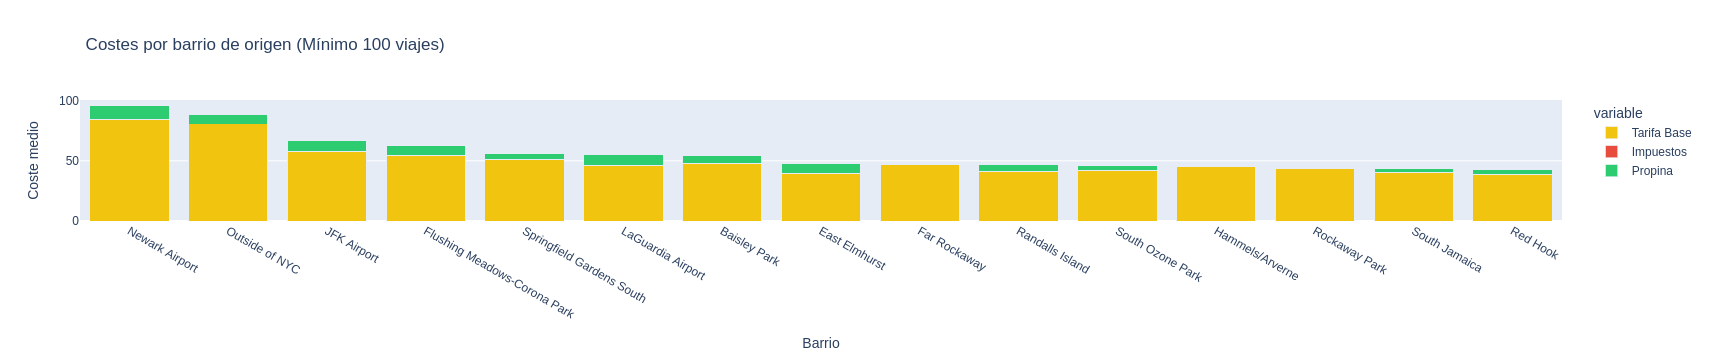

In [8]:
import plotly.express as px

costes_por_zona = df_con_nombres.groupby('Barrio_Origen').agg(
    fare_amount=('fare_amount', 'mean'),
    mta_tax=('mta_tax', 'mean'),
    tip_amount=('tip_amount', 'mean'),
    numero_viajes=('fare_amount', 'count') 
).reset_index()

costes_por_zona = costes_por_zona[costes_por_zona['numero_viajes'] >= 100]

costes_por_zona['coste_total_medio'] = costes_por_zona['fare_amount'] + costes_por_zona['mta_tax'] + costes_por_zona['tip_amount']
top_15_zonas = costes_por_zona.nlargest(15, 'coste_total_medio')

fig = px.bar(
    top_15_zonas, 
    x='Barrio_Origen', 
    y=['fare_amount', 'mta_tax', 'tip_amount'],
    title='Costes por barrio de origen (Mínimo 100 viajes)',
    labels={'value': 'Coste medio', 'Barrio_Origen': 'Barrio'},
    barmode='stack',
    color_discrete_sequence=['#f1c40f', '#e74c3c', '#2ecc71']
)

newnames = {'fare_amount': 'Tarifa Base', 'mta_tax': 'Impuestos', 'tip_amount': 'Propina'}
fig.for_each_trace(lambda t: t.update(name=newnames[t.name]))
fig.show()

Ahora sí los datos agrupados son más consistentes y en principio este gráfico reciclado representaría mejor la realidad sobre el aspecto ecónomico.

## Pregunta 4 : *¿Cómo afecta directamente cada minuto de tráfico al bolsillo del pasajero?*

Vamos finalmente a conectar las variables más significativas 'tiempo' vs 'costes', con este Scatter Plot vamos a poder darnos cuenta si es lo mismo estar atrapado 20 minutos en Times Square 
que 20 minutos volando por la autopista. Como no nos interesa ver miles de puntos, vamos a coger una muestra de 5000 viajes eliminando valores extremos.

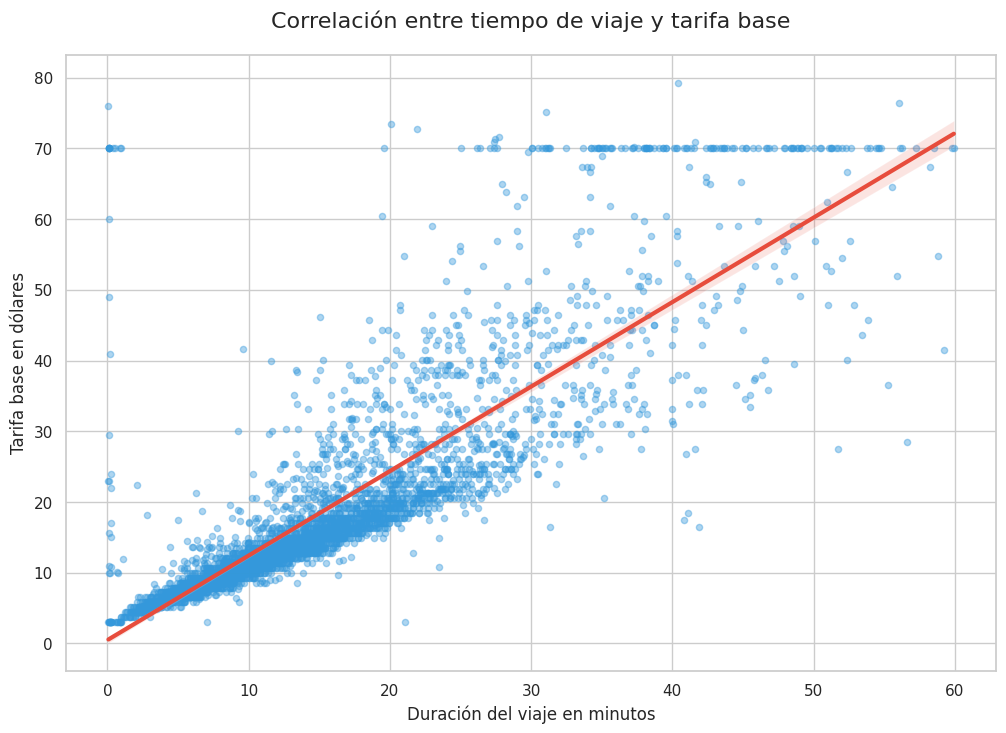

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df_scatter = df.sample(n=5000, random_state=42).copy()
df_scatter = df_scatter[(df_scatter['duracion_minutos'] > 0) & (df_scatter['duracion_minutos'] < 60)]
df_scatter = df_scatter[(df_scatter['fare_amount'] > 0) & (df_scatter['fare_amount'] < 80)]
df_scatter_nombres = pd.merge(
    df_scatter,
    df_diccionario,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)


plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.regplot(
    data=df_scatter_nombres,
    x='duracion_minutos',
    y='fare_amount',
    scatter_kws={'alpha': 0.4, 'color': '#3498db', 's': 20}, 
    line_kws={'color': '#e74c3c', 'linewidth': 3}            
)

plt.title('Correlación entre tiempo de viaje y tarifa base', fontsize=16, pad=20)
plt.xlabel('Duración del viaje en minutos', fontsize=12)
plt.ylabel('Tarifa base en dólares', fontsize=12)

plt.show()

La línea roja ascendente confirma que por norma general, a más minutos de viaje, más cara es la tarifa, hasta aquí todo normal, veo también un segmento horizontal en los 70 dólares, esto pueden ser
perfectamente tarifas planas de aeropuerto a hotel o viceversa. Se presentan claramente viajes inconsistentes de nula duración pero con costos elevados, como mencioné antes quizás esto se deba a errores de medición de tiempo por parte de los taxímetros o  microcortes en la comunicación con el servidor central ect. Y como podríamos esperar, a mayor tiempo de duración tienen los viajes, vemos que mayor es la dispersión de los datos a la contra y al revés, como pudimos comprobar antes, esto sucede ya que el coste que va a asumir el pasajero está directamente relacionado con donde solicita de primera el servicio.